In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
plt.rcParams["figure.dpi"] = 200
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
fig_size = (16, 2)

In [2]:
DATASET_PATH = './data/CAU-4329-Fjord5G-bandwidth-processed.parquet.gzip'

df = pd.read_parquet(DATASET_PATH)
df.info(verbose=True, show_counts=True, memory_usage='deep')

<class 'pandas.DataFrame'>
DatetimeIndex: 171755 entries, 2024-12-12 09:46:06 to 2025-04-23 14:22:46
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CQI                 171755 non-null  float32
 1   RSRP                171755 non-null  float32
 2   RSRQ                171755 non-null  float32
 3   SINR                171755 non-null  float32
 4   Tx-BW               171755 non-null  int32  
 5   Handover            171755 non-null  float32
 6   Handover_predicted  171755 non-null  float32
 7   Speed               171755 non-null  float32
 8   BandMHz             171755 non-null  int32  
 9   TDD_FDD             171755 non-null  int32  
 10  Band_n3             171755 non-null  float32
 11  Band_n78            171755 non-null  float32
 12  Predictions         171755 non-null  int32  
 13  Probabilities       171755 non-null  float32
dtypes: float32(10), int32(4)
memory usage: 10.5 MB


In [3]:
df.head()

,CQI,RSRP,RSRQ,SINR,Tx-BW,Handover,Handover_predicted,Speed,BandMHz,TDD_FDD,Band_n3,Band_n78,Predictions,Probabilities
timestamp_router,,,,,,,,,,,,,,
2024-12-12 09:46:06,8.0,-87.0,-10.0,6.0,17814688,1.0,0.0,12.813988,80,1,0.0,1.0,0,0.008662
2024-12-12 09:46:07,8.0,-87.0,-10.0,6.0,9726720,0.0,1.0,12.767688,80,1,0.0,1.0,0,0.015756
2024-12-12 09:46:08,7.0,-91.0,-11.0,3.0,19644160,1.0,1.0,12.875104,80,1,0.0,1.0,0,0.375591
2024-12-12 09:46:09,7.0,-91.0,-11.0,3.0,17164800,1.0,1.0,12.893624,80,1,0.0,1.0,0,0.019457
2024-12-12 09:46:10,7.0,-91.0,-11.0,3.0,9631360,1.0,1.0,12.984372,80,1,0.0,1.0,0,0.041513


In [4]:
df.keys()

Index(['CQI', 'RSRP', 'RSRQ', 'SINR', 'Tx-BW', 'Handover',
       'Handover_predicted', 'Speed', 'BandMHz', 'TDD_FDD', 'Band_n3',
       'Band_n78', 'Predictions', 'Probabilities'],
      dtype='str')

<Axes: xlabel='timestamp_router'>

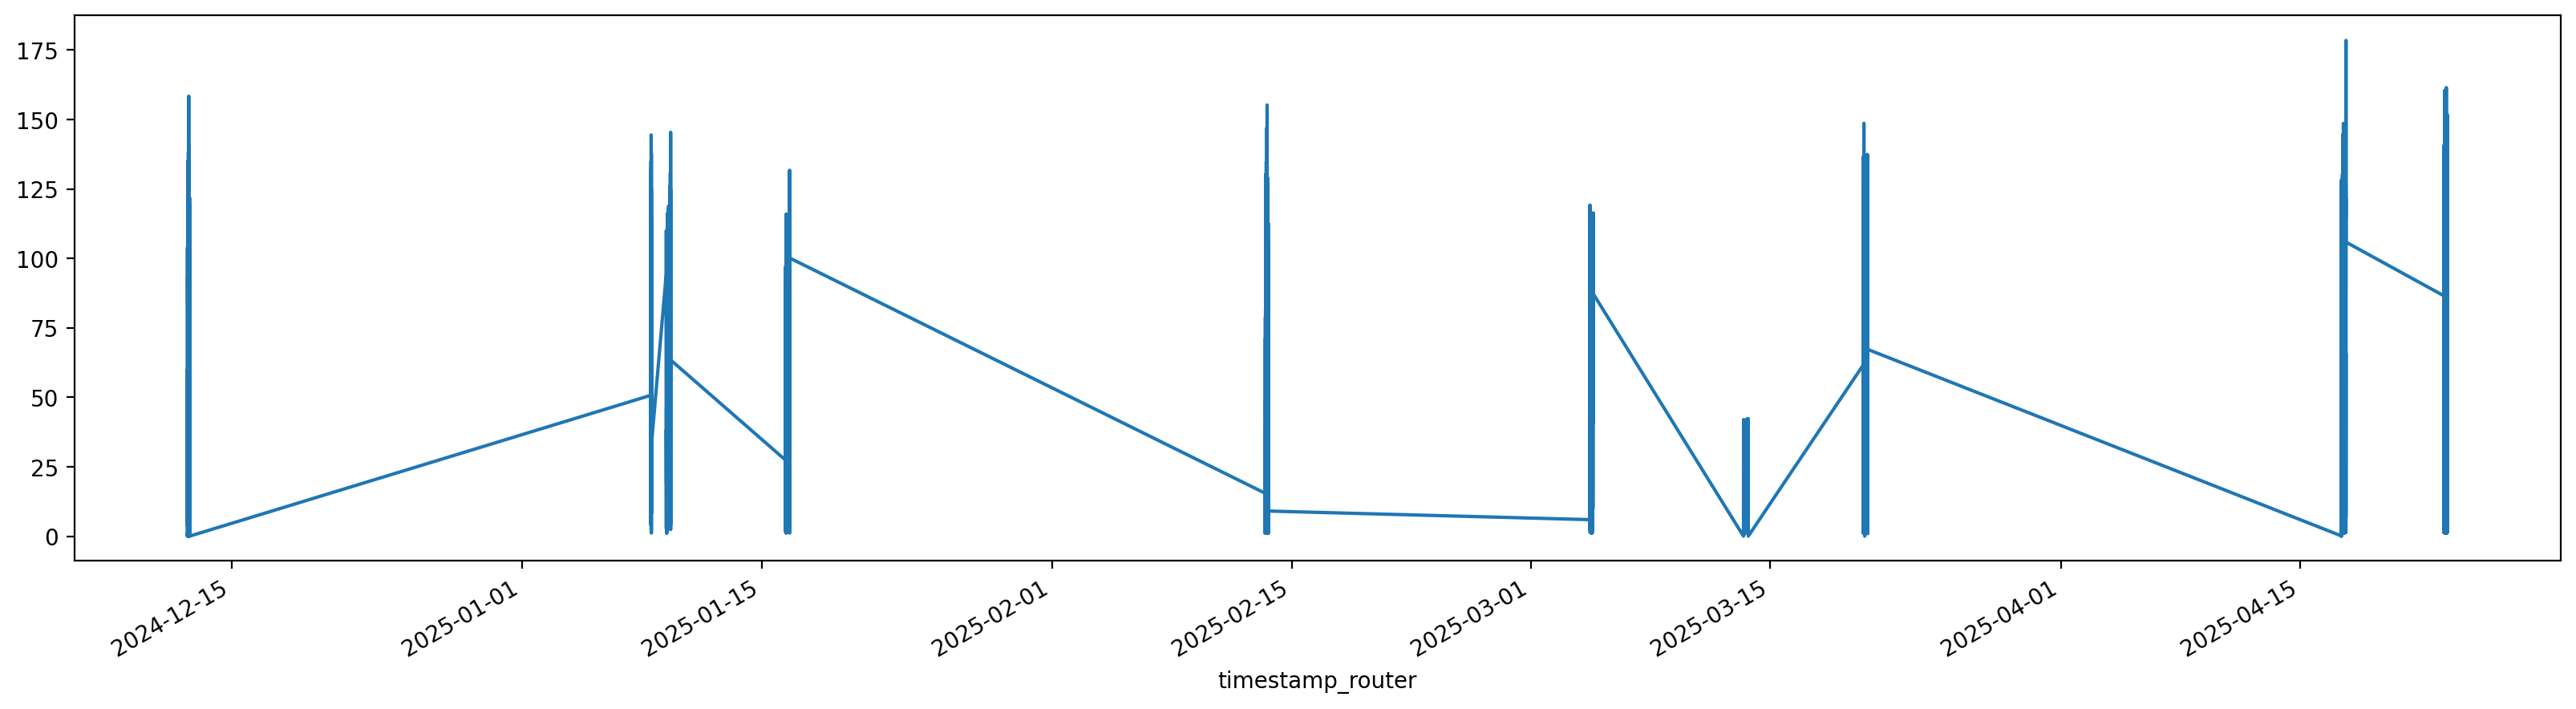

In [5]:
df['Tx-BW'].div(1000 * 1000).plot(figsize=(20, 5))

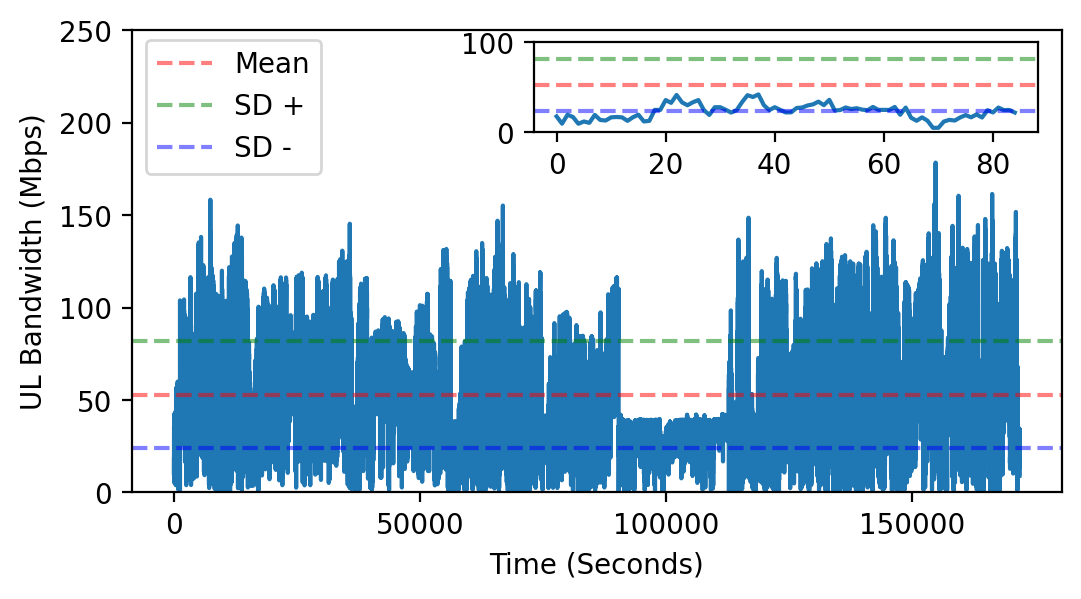

In [6]:
df.reset_index(drop=True, inplace=True)

# Calculate mean and standard deviation
mean_value = df['Tx-BW'].div(1000*1000).mean()
std_value = df['Tx-BW'].div(1000*1000).std()

figure_size = (6, 3)
fig, ax1 = plt.subplots(figsize=figure_size, dpi=200)
ax1.set_xlabel('Time (Seconds)')
ax1.set_ylabel('UL Bandwidth (Mbps)')
ax1.set_ylim(bottom=0, top=250)
#ax1.set_xlim(left=0, right=155000)

left, bottom, width, height = [0.46, 0.71, 0.42, 0.15]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.set_ylim(bottom=0, top=100)

ax1.plot(df['Tx-BW'].div(1000*1000))

alpha_val = 0.5
# Plot mean and standard deviation lines on ax1
ax1.axhline(mean_value, color='r', linestyle='--', alpha=alpha_val, label='Mean')
ax1.axhline(mean_value + std_value, color='g', linestyle='--', alpha=alpha_val, label='SD +')
ax1.axhline(mean_value - std_value, color='b', linestyle='--', alpha=alpha_val, label='SD -')

# explicitly choose tick positions
ticks = [0, 50000, 100000, 150000]
ax1.set_xticks(ticks)

# Add legend
ax1.legend(loc='lower left', bbox_to_anchor=(0, 0.66))

ax2.plot(df['Tx-BW'].div(1000*1000)[:85])
# Plot mean and standard deviation lines on ax2
ax2.axhline(mean_value, color='r', linestyle='--', alpha=alpha_val, label='Mean')
ax2.axhline(mean_value + std_value, color='g', linestyle='--', alpha=alpha_val, label='SD +')
ax2.axhline(mean_value - std_value, color='b', linestyle='--', alpha=alpha_val, label='SD -')
#fig.savefig(f'plots/Fjord5G-CAU-4329-uplink-data.pdf', bbox_inches='tight')